# GMM_case.ipynb

本 notebook 对应 `GMM_lec.qmd` 的案例部分，目标不是穷尽所有 GMM 变体，而是通过三类典型任务建立直觉：

- Case 1：过度识别 IV + 异方差
- Case 2a：Euler 方程的非线性 GMM（模拟数据）
- Case 2b：Euler 方程的非线性 GMM（真实数据，可选）
- Case 3：横截面资产定价中的多方程 GMM（可选）

数据默认来自 `GMM_codes.ipynb` 生成的 `./data/` 文件。若某个数据文件尚未生成，请先运行对应的素材 notebook 模块。


In [ ]:
# ============================================================
# 0. 依赖包检查
# ============================================================

try:
    from linearmodels.iv import IV2SLS, IVGMM
    print('linearmodels 已安装 ✓')
except ImportError:
    print('请先安装 linearmodels：pip install linearmodels')


In [3]:
# ============================================================
# 1. 通用依赖包与绘图设定
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm

#中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

COLOR_PRIMARY   = '#2C6BAC'
COLOR_SECONDARY = '#E8A020'
COLOR_NEUTRAL   = '#888888'
COLOR_FILL      = '#D6E8F7'
COLOR_GREEN     = '#2CA02C'
COLOR_RED       = '#D62728'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

DATA_DIR = './data'
FIG_DIR = './figs'
os.makedirs(FIG_DIR, exist_ok=True)

def display_header(title):
    print('\n' + '=' * 70)
    print(title)
    print('=' * 70)

def try_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


## Case 1：过度识别 IV + 异方差——有效 GMM vs. 2SLS

**背景**：使用模拟数据 `method_GMM_data01_iv_hetero.csv`。数据生成过程中，`x` 是内生变量，有 4 个工具变量，且误差项存在异方差。  
**研究问题**：有效 GMM 与 2SLS 在系数估计和标准误上有什么差异？  
**分析目标**：

- 验证三种估计量的点估计通常接近
- 展示异方差下标准误和检验统计量的差异
- 说明 Sargan 与 Hansen J 在稳健设定下的解读区别



Case 1：读取数据并查看异方差特征
      y     x    z1    z2    z3    z4     v  sigma   eps
0  1.27  0.50  1.67 -1.65  1.39 -0.92  0.05   0.75 -0.49
1 -1.03 -0.11  0.74  0.18  0.16  0.19 -0.63   0.55 -1.87
2  5.88  1.37 -0.20  0.12 -0.43 -0.12  1.57   1.18  2.82
3  1.63  0.68 -0.15  1.73 -0.67 -1.45  0.49   0.84 -0.40
4  4.81  2.16  0.92  1.34  0.26 -1.80  1.36   1.58  0.56
            y       x      z1      z2      z3      z4       v   sigma     eps
count  500.00  500.00  500.00  500.00  500.00  500.00  500.00  500.00  500.00
mean     1.11    0.04   -0.03    0.07   -0.05   -0.01    0.04    1.02    0.05
std      2.51    1.27    1.06    0.97    1.02    1.03    1.02    0.37    1.15
min     -7.39   -3.25   -3.42   -3.67   -2.90   -2.67   -3.17    0.50   -4.73
25%     -0.45   -0.84   -0.71   -0.57   -0.80   -0.70   -0.66    0.73   -0.60
50%      1.10    0.02   -0.05    0.06   -0.03   -0.01    0.06    0.93    0.06
75%      2.48    0.91    0.66    0.76    0.58    0.74    0.76    1.25    0.68
max      9.18

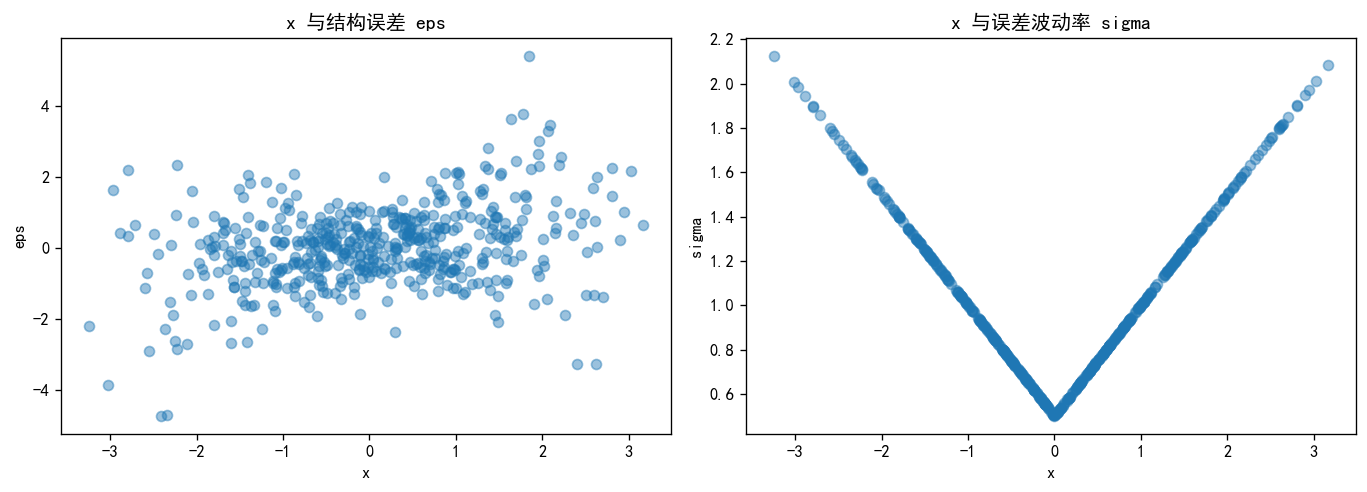

In [6]:
# ============================================================
# Case 1 - Step 1：读取数据并做图形化检查
# ============================================================

display_header('Case 1：读取数据并查看异方差特征')

df1 = pd.read_csv(f'{DATA_DIR}/method_GMM_data01_iv_hetero.csv')
print(df1.head().round(2))
print(df1.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].scatter(df1['x'], df1['eps'], alpha=0.45)
axes[0].set_title('x 与结构误差 eps')
axes[0].set_xlabel('x')
axes[0].set_ylabel('eps')

axes[1].scatter(df1['x'], df1['sigma'], alpha=0.45)
axes[1].set_title('x 与误差波动率 sigma')
axes[1].set_xlabel('x')
axes[1].set_ylabel('sigma')

plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# Case 1 - Step 2：2SLS（经典标准误）、2SLS-robust、两步 GMM
# ============================================================

display_header('Case 1：估计 2SLS 与 GMM')

y = df1['y']
X_exog = pd.DataFrame({'const': 1.0})
X_endog = df1['x']
Z = df1[['z1', 'z2', 'z3', 'z4']]

res_2sls = IV2SLS(y, X_exog, X_endog, Z).fit(cov_type='unadjusted')
res_2sls_robust = IV2SLS(y, X_exog, X_endog, Z).fit(cov_type='robust')
res_gmm = IVGMM(y, X_exog, X_endog, Z, weight_type='robust').fit(cov_type='robust')

print('--- 2SLS（经典标准误）---')
print(res_2sls.summary)
print('\n--- 2SLS（异方差稳健标准误）---')
print(res_2sls_robust.summary)
print('\n--- 两步 GMM（稳健权重）---')
print(res_gmm.summary)



Case 1：估计 2SLS 与 GMM


ValueError: If using all scalar values, you must pass an index

In [8]:
# ============================================================
# Case 1 - Step 3：结果对比表
# ============================================================

display_header('Case 1：结果对比表')

compare = pd.DataFrame({
    'method': ['True value', '2SLS', '2SLS-robust', 'IV-GMM'],
    'beta_x': [1.5,
               try_float(res_2sls.params['x']),
               try_float(res_2sls_robust.params['x']),
               try_float(res_gmm.params['x'])],
    'se_x': [np.nan,
             try_float(res_2sls.std_errors['x']),
             try_float(res_2sls_robust.std_errors['x']),
             try_float(res_gmm.std_errors['x'])],
})

print(compare.round(4))

print('\n解读建议：')
print('1. 三个估计量的系数通常比较接近，因为它们都基于同一组有效工具变量。')
print('2. 经典 2SLS 标准误若明显偏小，通常意味着同方差设定不合适。')
print('3. 2SLS-robust 与 GMM 的差别更多体现在效率与检验框架，而不只是“有没有 robust”。')



Case 1：结果对比表


NameError: name 'res_2sls' is not defined

In [9]:
# ============================================================
# Case 1 - Step 4：过度识别检验与内生性检验
# ============================================================

display_header('Case 1：关键检验统计量')

print('Hansen J（来自 IV-GMM）')
try:
    print(res_gmm.j_stat)
except Exception as e:
    print(f'无法直接读取 Hansen J：{e}')

print('\nSargan（来自 2SLS）')
try:
    print(res_2sls.sargan)
except Exception as e:
    print(f'无法直接读取 Sargan：{e}')

print('\nWu-Hausman 内生性检验')
try:
    print(res_2sls_robust.wu_hausman())
except Exception as e:
    print(f'无法直接读取 Wu-Hausman：{e}')



Case 1：关键检验统计量
Hansen J（来自 IV-GMM）
无法直接读取 Hansen J：name 'res_gmm' is not defined

Sargan（来自 2SLS）
无法直接读取 Sargan：name 'res_2sls' is not defined

Wu-Hausman 内生性检验
无法直接读取 Wu-Hausman：name 'res_2sls_robust' is not defined


::: {.callout-note collapse="true"}
### Stata 对应代码

```stata
import delimited "./data/method_GMM_data01_iv_hetero.csv", clear

* 2SLS（经典标准误）
ivreg2 y (x = z1 z2 z3 z4)

* 2SLS（异方差稳健标准误）
ivreg2 y (x = z1 z2 z3 z4), robust

* 两步有效 GMM
ivreg2 y (x = z1 z2 z3 z4), gmm2s robust
```

:::


## Case 2a：Euler 方程 GMM——模拟数据版

**背景**：使用模拟数据 `method_GMM_data02_euler_simulated.csv`。  
**真实参数**：`beta = 0.98`，`gamma = 2.0`。  
**矩条件**：

$$
E_t\left[\beta \left(\frac{c_{t+1}}{c_t}\right)^{-\gamma} R_{t+1} - 1 \right] \cdot z_t = 0
$$

其中，工具变量向量取为 `z_t = (1, dc_lag1, R_lag1, dc_lag2, R_lag2)`。  
**分析目标**：理解非线性 GMM 如何只依赖 Euler 方程矩条件估计参数。



Case 2a：读取 Euler 方程模拟数据
     dc     R  dc_lag1  dc_lag2  R_lag1  R_lag2
0  1.00  1.01     1.02     1.04    1.18    1.16
1  1.00  1.04     1.00     1.02    1.01    1.18
2  1.02  1.05     1.00     1.00    1.04    1.01
3  1.03  1.13     1.02     1.00    1.05    1.04
4  0.95  0.98     1.03     1.02    1.13    1.05
           dc       R  dc_lag1  dc_lag2  R_lag1  R_lag2
count  198.00  198.00   198.00   198.00  198.00  198.00
mean     1.01    1.03     1.01     1.01    1.03    1.03
std      0.02    0.07     0.02     0.02    0.07    0.07
min      0.95    0.83     0.95     0.95    0.83    0.83
25%      0.99    0.98     0.99     0.99    0.99    0.99
50%      1.01    1.02     1.01     1.01    1.02    1.03
75%      1.02    1.07     1.02     1.02    1.07    1.07
max      1.06    1.18     1.06     1.06    1.18    1.18


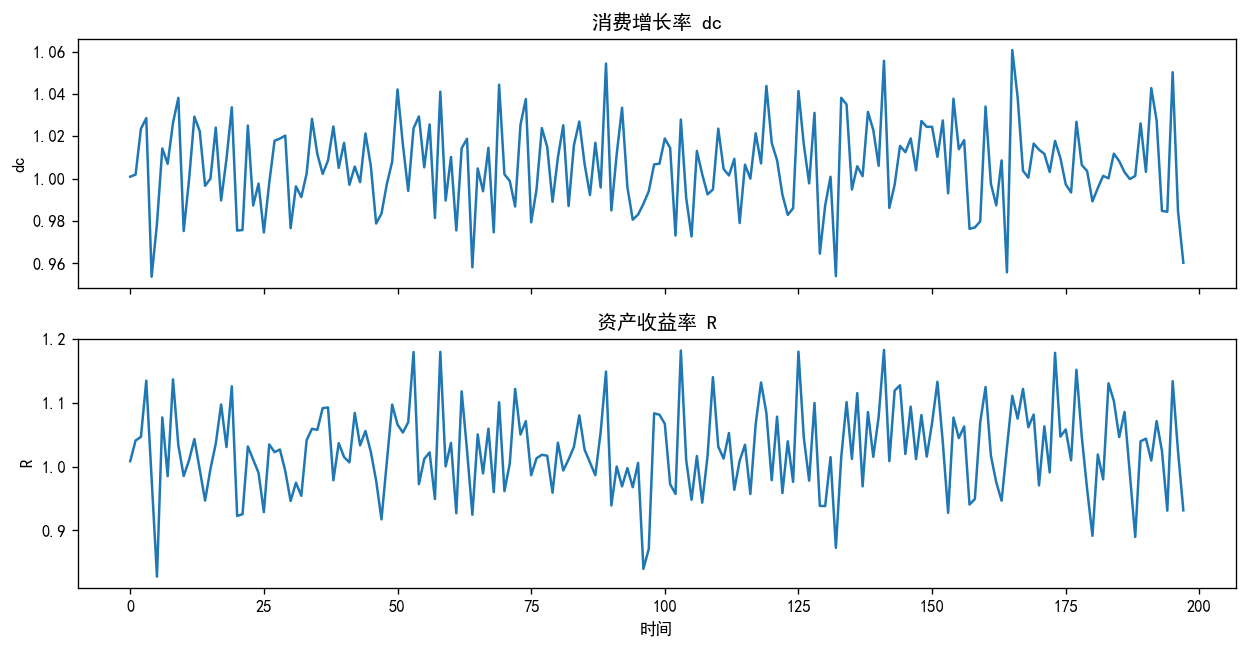

In [11]:
# ============================================================
# Case 2a - Step 1：读取数据并做描述
# ============================================================

display_header('Case 2a：读取 Euler 方程模拟数据')

df2 = pd.read_csv(f'{DATA_DIR}/method_GMM_data02_euler_simulated.csv')
print(df2.head().round(2))
print(df2.describe().round(2))

fig, axes = plt.subplots(2, 1, figsize=(10.5, 5.5), sharex=True)
axes[0].plot(df2['dc'].values, linewidth=1.5)
axes[0].set_title('消费增长率 dc')
axes[0].set_ylabel('dc')

axes[1].plot(df2['R'].values, linewidth=1.5)
axes[1].set_title('资产收益率 R')
axes[1].set_ylabel('R')
axes[1].set_xlabel('时间')

plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# Case 2a - Step 2：构造矩条件函数
# ============================================================

display_header('Case 2a：构造矩条件函数')

dc = df2['dc'].to_numpy()
R = df2['R'].to_numpy()

instruments = np.column_stack([
    np.ones(len(df2)),
    df2['dc_lag1'].to_numpy(),
    df2['R_lag1'].to_numpy(),
    df2['dc_lag2'].to_numpy(),
    df2['R_lag2'].to_numpy(),
])

def moment_conditions(params, dc, R, instruments):
    # params = [beta, gamma]
    beta, gamma = params
    residual = beta * dc ** (-gamma) * R - 1
    g = instruments * residual[:, np.newaxis]
    return g.mean(axis=0)

def gmm_objective_step1(params, dc, R, instruments):
    g_bar = moment_conditions(params, dc, R, instruments)
    return g_bar @ g_bar

def compute_S_hat(params, dc, R, instruments):
    beta, gamma = params
    residual = beta * dc ** (-gamma) * R - 1
    g_each = instruments * residual[:, np.newaxis]
    g_dm = g_each - g_each.mean(axis=0, keepdims=True)
    return g_dm.T @ g_dm / len(dc)

def gmm_objective_step2(params, dc, R, instruments, W):
    g_bar = moment_conditions(params, dc, R, instruments)
    return g_bar @ W @ g_bar

print('矩条件函数与目标函数已定义。')
print('矩条件个数 q =', instruments.shape[1], '；参数个数 k = 2')



Case 2a：构造矩条件函数
矩条件函数与目标函数已定义。
矩条件个数 q = 5 ；参数个数 k = 2


In [14]:
# ============================================================
# Case 2a - Step 3：两步 GMM 估计
# ============================================================

display_header('Case 2a：两步 GMM 估计')

theta0 = np.array([0.95, 1.50])

res1 = minimize(
    gmm_objective_step1,
    x0=theta0,
    args=(dc, R, instruments),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-10}
)
theta1 = res1.x

S_hat = compute_S_hat(theta1, dc, R, instruments)
W2 = np.linalg.pinv(S_hat)

res2 = minimize(
    gmm_objective_step2,
    x0=theta1,
    args=(dc, R, instruments, W2),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-10}
)
theta2 = res2.x

print('第一步估计值：', theta1.round(3))
print('第二步估计值：', theta2.round(3))



Case 2a：两步 GMM 估计
第一步估计值： [0.983 1.41 ]
第二步估计值： [0.977 0.444]


In [15]:
# ============================================================
# Case 2a - Step 4：Hansen J 检验与结果对比
# ============================================================

display_header('Case 2a：参数估计与 Hansen J')

g_hat = moment_conditions(theta2, dc, R, instruments)
T = len(dc)
df_overid = instruments.shape[1] - 2

J_stat = T * (g_hat @ W2 @ g_hat)
J_pval = 1 - stats.chi2.cdf(J_stat, df=df_overid)

results_case2a = pd.DataFrame({
    'parameter': ['beta', 'gamma'],
    'true_value': [0.98, 2.00],
    'estimate': theta2
})

print(results_case2a.round(4))
print(f'Hansen J = {J_stat:.4f}, df = {df_overid}, p-value = {J_pval:.4f}')



Case 2a：参数估计与 Hansen J
  parameter  true_value  estimate
0      beta        0.98    0.9770
1     gamma        2.00    0.4439
Hansen J = 2.6635, df = 3, p-value = 0.4465



Case 2a：目标函数热力图


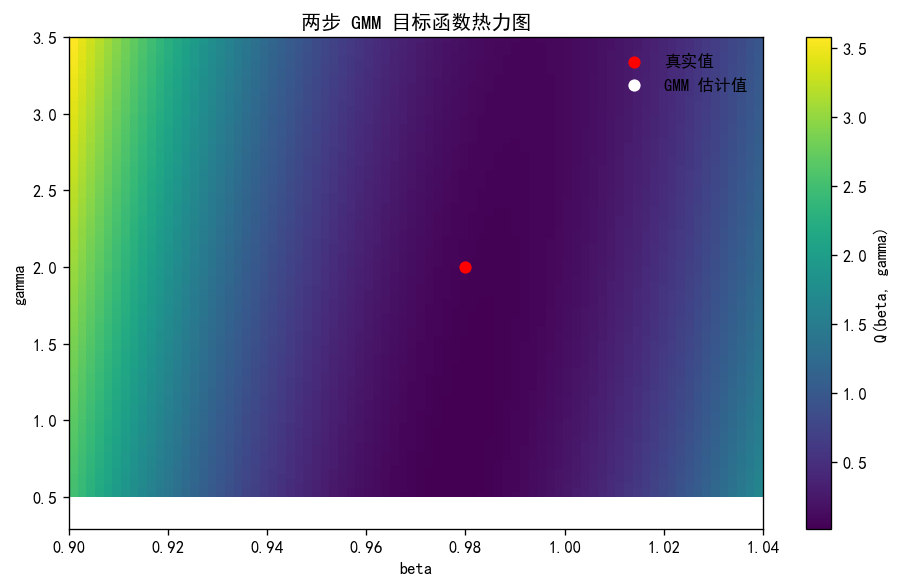

In [16]:
# ============================================================
# Case 2a - Step 5：参数空间热力图（建议模块）
# ============================================================

display_header('Case 2a：目标函数热力图')

beta_grid = np.linspace(0.90, 1.04, 80)
gamma_grid = np.linspace(0.5, 3.5, 100)
Q_grid = np.zeros((len(gamma_grid), len(beta_grid)))

for i, gg in enumerate(gamma_grid):
    for j, bb in enumerate(beta_grid):
        Q_grid[i, j] = gmm_objective_step2([bb, gg], dc, R, instruments, W2)

fig, ax = plt.subplots(figsize=(8.0, 5.0))
im = ax.imshow(
    Q_grid,
    origin='lower',
    aspect='auto',
    extent=[beta_grid.min(), beta_grid.max(), gamma_grid.min(), gamma_grid.max()]
)
ax.scatter([0.98], [2.0], color='red', s=40, label='真实值')
ax.scatter([theta2[0]], [theta2[1]], color='white', s=40, label='GMM 估计值')
ax.set_xlabel('beta')
ax.set_ylabel('gamma')
ax.set_title('两步 GMM 目标函数热力图')
ax.legend(frameon=False)
plt.colorbar(im, ax=ax, label='Q(beta, gamma)')
plt.tight_layout()
plt.show()


::: {.callout-note collapse="true"}
### Stata 对应代码

```stata
import delimited "./data/method_GMM_data02_euler_simulated.csv", clear

gmm (dc R dc_lag1 dc_lag2 R_lag1 R_lag2: ///
    ({beta}*(dc)^(-{gamma})*R - 1)), ///
    instruments(dc_lag1 dc_lag2 R_lag1 R_lag2) ///
    twostep winitial(identity)
```

:::


## Case 2b：Euler 方程 GMM——真实数据版（可选）

> **注意**：本节为可选模块。若本地没有 `./data/method_GMM_data04_euler_FRED.csv`，或者网络无法访问 FRED，可整体跳过本节，不影响其余案例。

**背景**：使用美国季度消费增长率与标普 500 超额收益率数据。  
**研究问题**：在真实宏观数据中，Euler 方程估计得到的 `beta` 与 `gamma` 是否落在文献常见区间内？


In [ ]:
# ============================================================
# Case 2b - Step 1：读取真实数据或跳过
# ============================================================

display_header('Case 2b：读取真实数据')

fpath = f'{DATA_DIR}/method_GMM_data04_euler_FRED.csv'
if not os.path.exists(fpath):
    print('未发现本地备份数据：', fpath)
    print('你可以先运行 GMM_codes.ipynb 中的数据 04 模块，或直接跳过本节。')
    df4 = None
else:
    df4 = pd.read_csv(fpath)
    print(df4.head())
    print(df4.describe().round(4))


In [ ]:
# ============================================================
# Case 2b - Step 2：若数据存在，则执行与 Case 2a 平行的 GMM 估计
# ============================================================

if df4 is not None:
    display_header('Case 2b：构造变量与两步 GMM')

    if 'pce_growth' in df4.columns:
        dc_real = 1 + df4['pce_growth'].to_numpy() / 100.0
    else:
        dc_real = df4.iloc[:, 1].to_numpy()

    if 'excess_ret' in df4.columns:
        R_real = 1 + df4['excess_ret'].to_numpy()
    else:
        R_real = 1 + df4.iloc[:, 2].to_numpy()

    tmp = pd.DataFrame({'dc': dc_real, 'R': R_real})
    tmp['dc_lag1'] = tmp['dc'].shift(1)
    tmp['dc_lag2'] = tmp['dc'].shift(2)
    tmp['R_lag1'] = tmp['R'].shift(1)
    tmp['R_lag2'] = tmp['R'].shift(2)
    tmp = tmp.dropna().reset_index(drop=True)

    dc_r = tmp['dc'].to_numpy()
    R_r = tmp['R'].to_numpy()
    inst_r = np.column_stack([
        np.ones(len(tmp)),
        tmp['dc_lag1'].to_numpy(),
        tmp['R_lag1'].to_numpy(),
        tmp['dc_lag2'].to_numpy(),
        tmp['R_lag2'].to_numpy()
    ])

    res1_r = minimize(
        gmm_objective_step1,
        x0=np.array([0.98, 2.0]),
        args=(dc_r, R_r, inst_r),
        method='Nelder-Mead',
        options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-10}
    )
    th1_r = res1_r.x
    S_r = compute_S_hat(th1_r, dc_r, R_r, inst_r)
    W_r = np.linalg.pinv(S_r)

    res2_r = minimize(
        gmm_objective_step2,
        x0=th1_r,
        args=(dc_r, R_r, inst_r, W_r),
        method='Nelder-Mead',
        options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-10}
    )
    th2_r = res2_r.x

    gbar_r = moment_conditions(th2_r, dc_r, R_r, inst_r)
    J_r = len(dc_r) * gbar_r @ W_r @ gbar_r
    p_r = 1 - stats.chi2.cdf(J_r, df=inst_r.shape[1] - 2)

    out = pd.DataFrame({
        'parameter': ['beta', 'gamma'],
        'estimate': th2_r
    })
    print(out.round(4))
    print(f'Hansen J = {J_r:.4f}, p-value = {p_r:.4f}')
    print('解释提示：若 gamma 很大，往往会引出股权溢价之谜的讨论。')
else:
    print('本节已跳过。')


## Case 3：横截面资产定价检验——多方程 GMM（可选）

**背景**：使用模拟数据 `method_GMM_data03_asset_pricing.csv`，包含 25 个资产组合与市场超额收益率。  
**研究问题**：市场风险溢价如何估计？若考虑资产收益之间的截面相关性，GMM 与 Fama-MacBeth 会有什么不同？

说明：

- 这里给出一个“教学版”的多方程 GMM 实现
- 目标不是复刻完整资产定价文献，而是帮助学生理解“多资产矩条件可以联合估计”



Case 3：读取资产定价模拟数据
   time  asset  excess_ret  mkt_excess  beta_true
0     0      0       0.030       0.073      0.500
1     0      1       0.021       0.073      0.542
2     0      2       0.049       0.073      0.583
3     0      3       0.054       0.073      0.625
4     0      4       0.033       0.073      0.667
           time     asset  excess_ret  mkt_excess  beta_true
count  1500.000  1500.000    1500.000    1500.000   1500.000
mean     29.500    12.000       0.006       0.008      1.000
std      17.324     7.214       0.046       0.038      0.301
min       0.000     0.000      -0.168      -0.099      0.500
25%      14.750     6.000      -0.023      -0.011      0.750
50%      29.500    12.000       0.009       0.008      1.000
75%      44.250    18.000       0.037       0.041      1.250
max      59.000    24.000       0.134       0.079      1.500


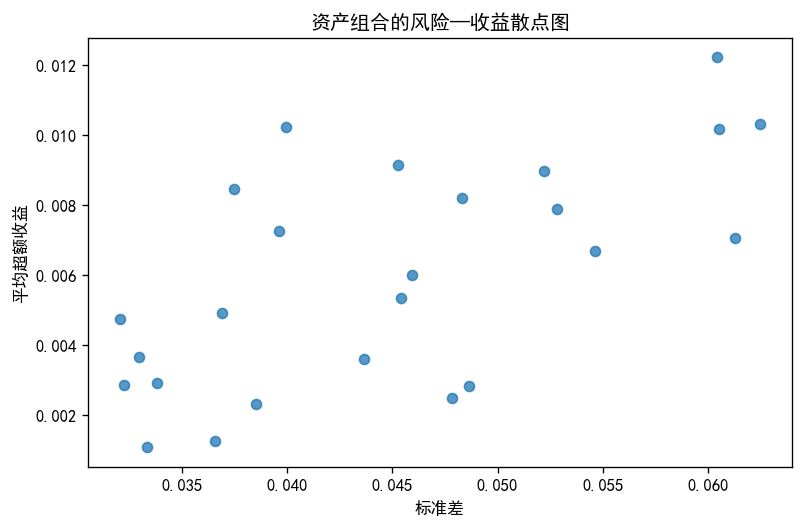

In [19]:
# ============================================================
# Case 3 - Step 1：读取数据与描述统计
# ============================================================

display_header('Case 3：读取资产定价模拟数据')

df3 = pd.read_csv(f'{DATA_DIR}/method_GMM_data03_asset_pricing.csv')
print(df3.head().round(3))
print(df3.describe().round(3))

mean_std = df3.groupby('asset')['excess_ret'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.scatter(mean_std['std'], mean_std['mean'], alpha=0.75)
ax.set_xlabel('标准差')
ax.set_ylabel('平均超额收益')
ax.set_title('资产组合的风险—收益散点图')
plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# Case 3 - Step 2：逐资产时序回归，估计 beta_i
# ============================================================

display_header('Case 3：第一步时序回归')

beta_hats = []
mean_rets = []

for asset_id, sub in df3.groupby('asset'):
    X = sm.add_constant(sub['mkt_excess'])
    y = sub['excess_ret']
    res = sm.OLS(y, X).fit()
    beta_hats.append({'asset': asset_id, 'beta_hat': res.params['mkt_excess']})
    mean_rets.append({'asset': asset_id, 'mean_ret': y.mean()})

beta_hats = pd.DataFrame(beta_hats)
mean_rets = pd.DataFrame(mean_rets)

asset_df = beta_hats.merge(mean_rets, on='asset')
print(asset_df.head())



Case 3：第一步时序回归
   asset  beta_hat  mean_ret
0      0  0.619490  0.001084
1      1  0.579440  0.002872
2      2  0.648620  0.002908
3      3  0.653321  0.003655
4      4  0.651828  0.004761


In [ ]:
# ============================================================
# Case 3 - Step 3：Fama-MacBeth 风格的第二步横截面回归
# ============================================================

display_header('Case 3：Fama-MacBeth 风格横截面回归')

X_cs = sm.add_constant(asset_df['beta_hat'])
y_cs = asset_df['mean_ret']
res_cs = sm.OLS(y_cs, X_cs).fit()

print(res_cs.summary())
lambda_fm = res_cs.params['beta_hat']
print(f'风险溢价（横截面回归）lambda = {lambda_fm:.4f}')


In [ ]:
# ============================================================
# Case 3 - Step 4：一个教学版的多方程 GMM
# ============================================================

display_header('Case 3：教学版多方程 GMM')

mean_returns_panel = df3.pivot(index='time', columns='asset', values='excess_ret')
Sigma_hat = mean_returns_panel.cov().to_numpy() / mean_returns_panel.shape[0]
W = np.linalg.pinv(Sigma_hat)

betas_vec = asset_df['beta_hat'].to_numpy()
mean_vec = asset_df['mean_ret'].to_numpy()

def gmm_asset_objective(lam, mean_vec, betas_vec, W):
    alpha_vec = mean_vec - lam[0] * betas_vec
    return alpha_vec @ W @ alpha_vec

res_gmm_asset = minimize(
    gmm_asset_objective,
    x0=np.array([lambda_fm]),
    args=(mean_vec, betas_vec, W),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-10}
)

lambda_gmm = res_gmm_asset.x[0]
alpha_hat = mean_vec - lambda_gmm * betas_vec
J_case3 = alpha_hat @ W @ alpha_hat
p_case3 = 1 - stats.chi2.cdf(J_case3, df=len(alpha_hat) - 1)

print(f'Fama-MacBeth lambda = {lambda_fm:.4f}')
print(f'GMM lambda          = {lambda_gmm:.4f}')
print(f'J statistic         = {J_case3:.4f}')
print(f'J p-value           = {p_case3:.4f}')

compare_case3 = pd.DataFrame({
    'method': ['Fama-MacBeth-like', 'GMM'],
    'lambda_hat': [lambda_fm, lambda_gmm]
})
print(compare_case3.round(4))


::: {.callout-note collapse="true"}
### Stata 对应代码

```stata
import delimited "./data/method_GMM_data03_asset_pricing.csv", clear

xtset asset time
xtfmb excess_ret mkt_excess

* 多方程 GMM 的完整实现通常需要自己组织矩条件
* 这里建议将思路保留在讲义中，完整程序放在 Python notebook 中
```

:::


## 综合小结

| 案例 | 方法 | 矩条件来源 | 关键认识 |
|:---|:---|:---|:---|
| Case 1 | 有效 GMM vs. 2SLS | 工具变量正交性 | 异方差下，GMM 的稳健推断与效率组织更自然 |
| Case 2a / 2b | 非线性 GMM | Euler 方程 | 不需要完整分布，也能估计结构参数 |
| Case 3 | 多方程 GMM | 多资产正交性 | 可以利用方程间协方差结构组织信息 |

回扣全章主线：理论先给出矩条件，样本把它们变成样本矩偏离，研究者通过权重矩阵把这些偏离压缩成一个目标函数，再由数值优化或闭式表达得到参数估计。理解了这条链条，GMM 就不再只是一个命令，而是一套组织经验研究的方法。
